In [1]:
import numpy as np
import meep as mp

# 1. Define the geometry for a 1D bragg resonator
resolution = 100
time_units_fs = 20
rescaling = 0.47

pml_thickness = 2.0 * rescaling
t1 = 0.125 * rescaling
t2 = 0.25 * rescaling
n1 = 2.0
n2 = 1.0

nlayer = 5
layer_indexes = np.array([n2, n1] * nlayer + [1.0] + [n1, n2] * nlayer)
layer_thicknesses = np.array([t2, t1] * nlayer + [0.5 * rescaling] + [t1, t2] * nlayer)

layer_thicknesses[0] += pml_thickness
layer_thicknesses[-1] += pml_thickness
length = np.sum(layer_thicknesses)
layer_centers = np.cumsum(layer_thicknesses) - layer_thicknesses/2
layer_centers = layer_centers - length/2
cell_size = mp.Vector3(length, 0, 0)
pml_layers = [mp.PML(thickness=pml_thickness)]

geometry = [mp.Block(mp.Vector3(layer_thicknesses[i], mp.inf, mp.inf),
    center=mp.Vector3(layer_centers[i], 0, 0), material=mp.Medium(index=layer_indexes[i]))
    for i in range(layer_thicknesses.size)]

sourceLocation = mp.Vector3(layer_centers[0] + layer_thicknesses[0]/4, 0, 0)
transmissionMonitorLocation = mp.Vector3(layer_centers[-1]-pml_thickness/2-0.05, 0, 0)
reflectionMonitorLocation = mp.Vector3(layer_centers[0] + layer_thicknesses[0]/4 + 0.1, 0, 0)

frequency = 1.0 / rescaling  # target frequency in meep units
frequencyWidth = 1.8 / rescaling
numberFrequencies = 2000
sources = [mp.Source(
    mp.GaussianSource(frequency=frequency,fwidth=frequencyWidth),
    component=mp.Ez,
    center=sourceLocation,
    size=mp.Vector3(0.0, 0, 0)
    )]

# Perform simulation in vacuum first
sim = mp.Simulation(
    cell_size=cell_size,
    sources=sources,
    resolution=resolution,
    boundary_layers=pml_layers
)

incidentRegion = mp.FluxRegion(center=reflectionMonitorLocation, size=mp.Vector3(0.04, 0, 0), weight=1.0, direction=mp.X)
incidentFluxMonitor = sim.add_flux(frequency, frequencyWidth, numberFrequencies, incidentRegion)

sim.run(until_after_sources=4000 * rescaling)

Using MPI version 4.1, 1 processes
-----------
Initializing structure...
time for choose_chunkdivision = 5.1e-05 s
Working in 2D dimensions.
Computational cell is 3.88 x 0.01 x 0 with resolution 100
time for set_epsilon = 0.000356 s
-----------
Meep progress: 978.3000000000001/1882.611111164093 = 52.0% done in 4.0s, 3.7s to go
on time step 195660 (time=978.3), 2.04446e-05 s/step
run 0 finished at t = 1882.615 (376523 timesteps)


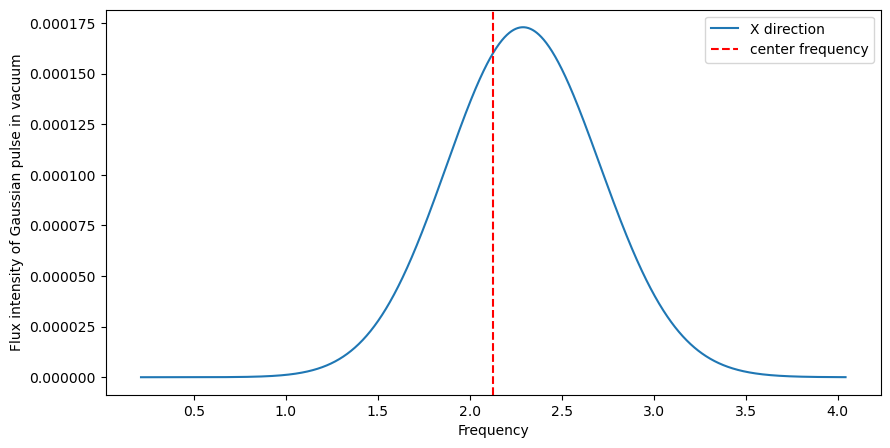

In [2]:
Flux_freq = mp.get_flux_freqs(incidentFluxMonitor)
Frequencies = np.array(Flux_freq)
Empty_Flux_int = mp.get_fluxes(incidentFluxMonitor)
Empty_Flux_data = sim.get_flux_data(incidentFluxMonitor)
Empty_Intensities = np.array(Empty_Flux_int)

import matplotlib.pyplot as plt
# Plot flux vs frequency
plt.figure(figsize=(10, 5))
plt.plot(Frequencies, Empty_Intensities, label="X direction")
plt.axvline(x=1.0/rescaling, color='r', linestyle='--', label='center frequency')
plt.xlabel('Frequency')
plt.ylabel('Flux intensity of Gaussian pulse in vacuum')
plt.legend(loc="upper right")
plt.grid(False)

In [3]:
incidentFluxToSubtract = sim.get_flux_data(incidentFluxMonitor)

# Perform simulation with the structure
sim = mp.Simulation(
    cell_size=cell_size,
    sources=sources,
    resolution=resolution,
    geometry=geometry,
    boundary_layers=pml_layers)

transmissionRegion = mp.FluxRegion(center=transmissionMonitorLocation, size=mp.Vector3(0.04, 0, 0), weight=1.0, direction=mp.X)
transmissionFluxMonitor = sim.add_flux(frequency, frequencyWidth, numberFrequencies, transmissionRegion)
reflectionRegion = incidentRegion
reflectionFluxMonitor = sim.add_flux(frequency, frequencyWidth, numberFrequencies, reflectionRegion)
sim.load_minus_flux_data(reflectionFluxMonitor, incidentFluxToSubtract)

sim.run(until_after_sources=4000 * rescaling)

-----------
Initializing structure...
time for choose_chunkdivision = 8.9e-05 s
Working in 2D dimensions.
Computational cell is 3.88 x 0.01 x 0 with resolution 100
     block, center = (-1.41,0,0)
          size (1.0575,1e+20,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     block, center = (-0.851875,0,0)
          size (0.05875,1e+20,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4,4,4)
     block, center = (-0.76375,0,0)
          size (0.1175,1e+20,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     block, center = (-0.675625,0,0)
          size (0.05875,1e+20,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4,4,4)
     block, center = (-0.5875,0,0)
          size (0.1175,1e+20,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diago

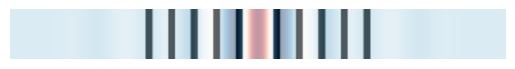

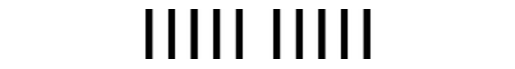

In [4]:
eps_data = sim.get_array(center=mp.Vector3(), size=cell_size, component=mp.Dielectric).reshape((-1,1))
ez_data = sim.get_array(center=mp.Vector3(), size=cell_size, component=mp.Ez).reshape((-1,1))
plt.figure()
plt.imshow(ez_data.transpose(), extent=[0,1,0,0.1], interpolation='spline36', cmap='RdBu')
plt.imshow(eps_data.transpose(), extent=[0,1,0,0.1], interpolation='spline36', cmap='binary', alpha=0.6)

plt.axis('off')
plt.show()

plt.figure()
plt.imshow(eps_data.transpose(), extent=[0,1,0,0.1], interpolation='spline36', cmap='binary')
plt.axis('off')
plt.show()

# save epsilon data to disk
np.savetxt("bragg_resonator_ez.txt", ez_data, header="Ez values", fmt="%10.6f")
np.savetxt("bragg_resonator_epsilon.txt", eps_data, header="Epsilon values", fmt="%10.6f")

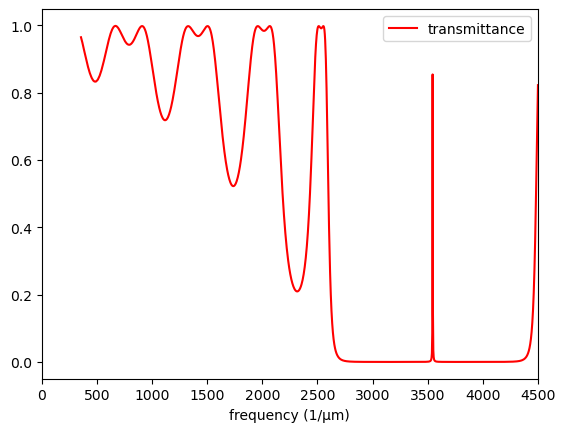

In [5]:
incidentFlux = np.array(mp.get_fluxes(incidentFluxMonitor))
transmittedFlux = np.array(mp.get_fluxes(transmissionFluxMonitor))
reflectedFlux = np.array(mp.get_fluxes(reflectionFluxMonitor))
freqs_output = np.array(mp.get_flux_freqs(reflectionFluxMonitor))
# convert meep frequencies to cm-1
freqs_output = freqs_output * rescaling * 3550.0
R = -reflectedFlux / incidentFlux
T = transmittedFlux / incidentFlux

import matplotlib.pyplot as plt
plt.figure()
# plt.plot(freqs_output,R,'b-',label='reflectance')
# plt.plot(freqs_output,1-R-T,'g-',label='loss')
plt.plot(freqs_output,T,'r-',label='transmittance')
plt.xlim(0, 4500)
plt.xlabel("frequency (1/μm)")
plt.legend(loc="upper right")
plt.show()

# save transmission data to disk
np.savetxt("bragg_resonator_transmission.txt", np.column_stack((freqs_output, T)), header="Frequency(cm-1)   Transmittance", fmt="%10.6f")